In [1]:
# ============================================
# 🚀 XGBoost (Feature Engineering + SMOTE)
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report, RocCurveDisplay
)

# --- 1️⃣ Load dataset ---
df = pd.read_csv("../Data/final_classification_ready_v2.csv")
print("Shape:", df.shape)
df.head()

# --- 2️⃣ Split data ---
X = df.drop(columns=["DEP_DEL15"])
y = df["DEP_DEL15"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train:", X_train.shape, "| Test:", X_test.shape)

# --- 3️⃣ Scale + SMOTE ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

sm = SMOTE(random_state=42)
X_train_bal, y_train_bal = sm.fit_resample(X_train_scaled, y_train)

print("Trước SMOTE:", np.bincount(y_train))
print("Sau SMOTE :", np.bincount(y_train_bal))

# --- 4️⃣ Train XGBoost ---
ratio = y_train.value_counts()[0] / y_train.value_counts()[1]

xgb_model = XGBClassifier(
    random_state=42,
    objective='binary:logistic',
    eval_metric='logloss',
    learning_rate=0.1,
    n_estimators=300,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=ratio,   # ⚖️ cân bằng loss
    use_label_encoder=False
)

xgb_model.fit(X_train_bal, y_train_bal)

# --- 5️⃣ Predict & Evaluate ---
y_pred = xgb_model.predict(X_test_scaled)
y_prob = xgb_model.predict_proba(X_test_scaled)[:, 1]

acc = accuracy_score(y_test, y_pred)
pre = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc = roc_auc_score(y_test, y_prob)

print("📊 XGBoost (Feature Eng + SMOTE) Performance:")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {pre:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-score : {f1:.4f}")
print(f"ROC-AUC  : {roc:.4f}")


Shape: (45155, 18)
Train: (36124, 17) | Test: (9031, 17)


C:\Users\PC\AppData\Local\Temp\ipykernel_30436\4230965935.py:42: DeprecationWarning: Non-integer input passed to bincount. In a future version of NumPy, this will be an error. (Deprecated NumPy 2.1)
  print("Trước SMOTE:", np.bincount(y_train))
C:\Users\PC\AppData\Local\Temp\ipykernel_30436\4230965935.py:43: DeprecationWarning: Non-integer input passed to bincount. In a future version of NumPy, this will be an error. (Deprecated NumPy 2.1)
  print("Sau SMOTE :", np.bincount(y_train_bal))
c:\Users\PC\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\training.py:183: UserWarning: [10:51:50] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Trước SMOTE: [31882  4242]
Sau SMOTE : [31882 31882]
📊 XGBoost (Feature Eng + SMOTE) Performance:
Accuracy : 0.6501
Precision: 0.1978
Recall   : 0.6481
F1-score : 0.3030
ROC-AUC  : 0.7018


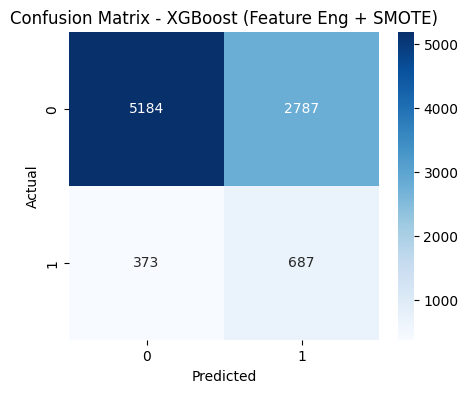

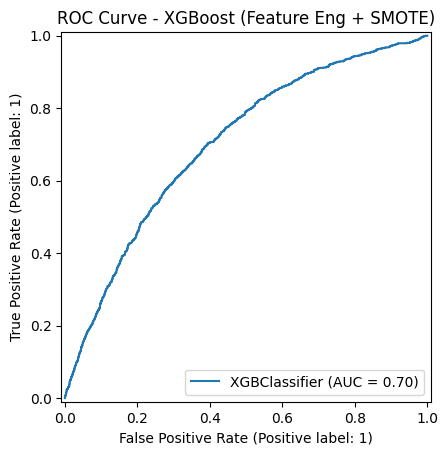

In [2]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - XGBoost (Feature Eng + SMOTE)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ROC Curve
RocCurveDisplay.from_estimator(xgb_model, X_test_scaled, y_test)
plt.title("ROC Curve - XGBoost (Feature Eng + SMOTE)")
plt.show()


In [3]:
print("Classification Report:\n")
print(classification_report(y_test, y_pred))


Classification Report:

              precision    recall  f1-score   support

         0.0       0.93      0.65      0.77      7971
         1.0       0.20      0.65      0.30      1060

    accuracy                           0.65      9031
   macro avg       0.57      0.65      0.53      9031
weighted avg       0.85      0.65      0.71      9031



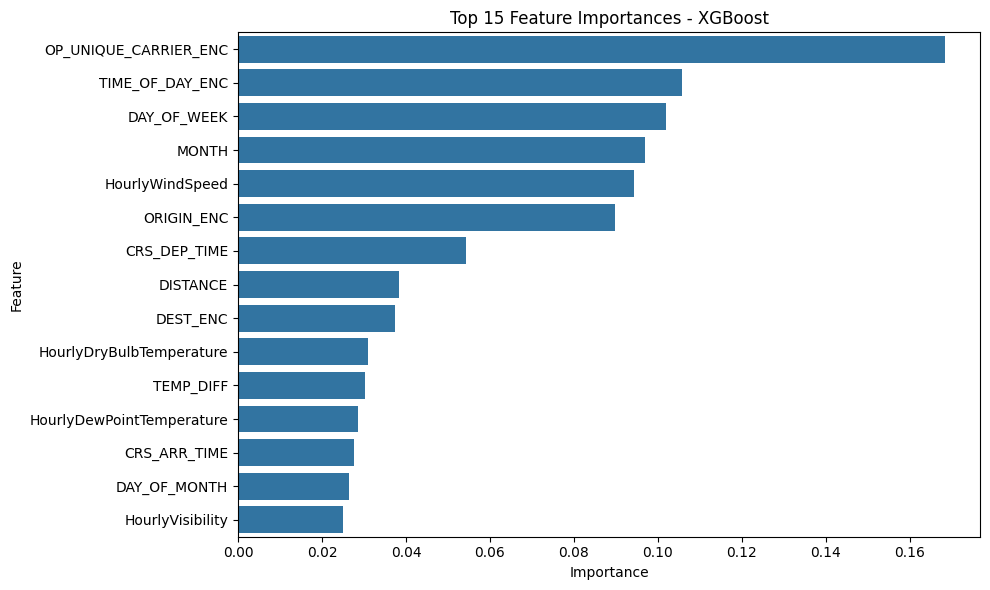

In [4]:
feat_imp = pd.DataFrame({
    "Feature": X.columns,
    "Importance": xgb_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x="Importance", y="Feature", data=feat_imp.head(15))
plt.title("Top 15 Feature Importances - XGBoost")
plt.tight_layout()
plt.show()
